# Getting the most out of GPT-5.4 for document and multimodal understanding

GPT-5.4 is a major step forward for real-world multimodal workloads.

Documents that previously broke vision models or required multiple systems to do OCR/ layout detection/custom parsing, such as dense scans, handwritten forms, engineering diagrams, and chart-heavy reports, can now be read and reasoned over reliably in a single model pass with GPT-5.4. 

However, model configuration is key for unlocking SOTA results. Small choices around image detail, verbosity, reasoning effort, and tool usage can significantly affect performance. 

This notebook walks through practical patterns for configuring robust multimodal pipelines with GPT-5.4.

## A quick decision guide

| If your task looks like this | Start with this setup | Why |
|---|---|---|
| Ordinary document QA or extraction | `detail="auto"` | Lowest-friction default for readable pages |
| Dense scans, screenshots, handwriting, or tiny labels | `detail="original"` | Preserves small visual signals that often get lost |
| Literal transcription or markdown conversion | `text={"verbosity": "high"}` | Encourages the model to keep more layout and fewer paraphrases |
| Region localization | Ask for `[x_min, y_min, x_max, y_max]` in a fixed `0..999` grid | Easy to crop, draw, debug, and feed into downstream systems |
| Chart, table, form, or drawing QA across multiple regions | increase reasoning effort to 'high' or 'xhigh' | Improves multi-step visual reasoning |
| Multi-pass visual inspection | Add Code Interpreter | Best when a human would zoom, crop, rotate, or inspect several subregions before answering |

## Setup

Run this once. It:

- imports the notebook dependencies
- creates the API client
- records the repo root used by the example paths below

Start Jupyter from the `openai-cookbook` repo root so the relative paths resolve correctly.

Install the required dependencies if needed:
```bash
pip install --upgrade openai pandas pillow
```

In [18]:
import base64
import json
import mimetypes
import os
import re
import tempfile
import time
import unicodedata
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, display
from PIL import Image, ImageDraw
from openai import OpenAI

client = OpenAI()

### Shared helpers

The next cell defines the small utilities used throughout the notebook.


In [19]:
def image_to_data_url(image_path: str | Path) -> str:
    path = Path(image_path)
    if not path.exists():
        raise FileNotFoundError(f"Image not found: {path}")
    mime_type = mimetypes.guess_type(path.name)[0] or "image/png"
    encoded = base64.b64encode(path.read_bytes()).decode("ascii")
    return f"data:{mime_type};base64,{encoded}"


def response_usage(response) -> dict:
    usage = getattr(response, "usage", None)
    if usage is None:
        return {}
    return usage.model_dump() if hasattr(usage, "model_dump") else dict(usage)


def extract_json(text: str):
    cleaned = text.strip()
    if cleaned.startswith("```"):
        cleaned = re.sub(r"^```(?:json)?\s*", "", cleaned)
        cleaned = re.sub(r"\s*```$", "", cleaned)

    candidates = [cleaned]
    for opening, closing in [("{", "}"), ("[", "]")]:
        start = cleaned.find(opening)
        end = cleaned.rfind(closing)
        if start != -1 and end != -1 and end > start:
            candidates.insert(0, cleaned[start : end + 1])

    for candidate in candidates:
        try:
            return json.loads(candidate)
        except json.JSONDecodeError:
            continue

    raise ValueError("Response did not contain valid JSON.")


def maybe_parse_json(text: str):
    try:
        return extract_json(text)
    except ValueError:
        return None



## 1. Increase image detail for dense pages and handwriting

The `detail` parameter controls the resolution the model uses when processing an image. Most applications should start with `detail="auto"` which lets the model choose an appropriate resolution. However, when pages contain handwriting, small labels, dense tables, low contrast scans, or screenshots with fine text, switching to `detail="original"` can significantly improve results. If the model is mostly correct but consistently misses small fields or annotations, increasing image detail is usually the first adjustment to try.

This example intentionally includes small email and phone fields, not just the larger handwritten names. Those are the kinds of details that tend to degrade first when the image is downsampled.

![Handwritten insurance form](../../images/3C_insurance_form.png)


In [22]:
handwriting_prompt = """
Read the handwritten earthquake insurance application and return JSON with these keys:
- applicant_name
- applicant_email
- applicant_home_phone
- applicant_cell_phone
- co_applicant_name
- co_applicant_email
- co_applicant_home_phone
- co_applicant_work_phone
- effective_date
- expiration_date
- dwelling_coverage_limit_usd
- square_footage
- year_of_construction

Rules:
- Copy names and emails exactly as written.
- Return phone numbers as plain strings with spaces preserved if visible.
- Return dates exactly as written.
- Normalize currency to an integer number of USD with no commas or dollar signs.
- Return integers for square footage and year.
- Return JSON only.
"""

handwriting_expected = {
    "applicant_name": "Smith, James L",
    "applicant_email": "jsmith1@gmail.com",
    "applicant_home_phone": "510 331 5555",
    "applicant_cell_phone": "510 212 5555",
    "co_applicant_name": "Roberts, Jesse T",
    "co_applicant_email": "jrobertsjr@gmail.com",
    "co_applicant_home_phone": "510 331 5555",
    "co_applicant_work_phone": "415 626 5555",
    "effective_date": "5/31/25",
    "expiration_date": "5/31/27",
    "dwelling_coverage_limit_usd": 900000,
    "square_footage": 1200,
    "year_of_construction": 2005,
}
handwriting_tolerances = {
    "dwelling_coverage_limit_usd": 0,
    "square_footage": 0,
    "year_of_construction": 0,
}


def score_handwriting_response(parsed: dict | None):
    def normalize_value(value):
        if value is None:
            return None
        text = unicodedata.normalize("NFKD", str(value))
        text = text.encode("ascii", "ignore").decode("ascii")
        text = text.lower()
        return re.sub(r"[^a-z0-9]+", " ", text).strip()

    def values_match(predicted, expected, tolerance: float | None = None) -> bool:
        if isinstance(expected, list):
            if not isinstance(predicted, list):
                predicted = [] if predicted is None else [predicted]
            left = sorted(normalize_value(item) for item in predicted if item is not None)
            right = sorted(normalize_value(item) for item in expected if item is not None)
            return left == right

        if isinstance(expected, (int, float)):
            try:
                predicted_float = float(predicted)
            except (TypeError, ValueError):
                return False
            tolerance = 0 if tolerance is None else tolerance
            return abs(predicted_float - float(expected)) <= tolerance

        return normalize_value(predicted) == normalize_value(expected)

    rows = []
    for field, expected_value in handwriting_expected.items():
        predicted_value = None if parsed is None else parsed.get(field)
        match = values_match(
            predicted_value,
            expected_value,
            handwriting_tolerances.get(field),
        )
        rows.append(
            {
                "field": field,
                "expected": expected_value,
                "predicted": predicted_value,
                "match": match,
            }
        )
    frame = pd.DataFrame(rows)
    accuracy = frame["match"].mean() if not frame.empty else 0.0
    return frame, accuracy


handwritten_form_path = f"../../images/3C_insurance_form.png"
handwritten_form_image_url = image_to_data_url(handwritten_form_path)
handwriting_model = "galapagos-alpha"

handwriting_results = []
for detail in ["auto", "original"]:
    started_at = time.perf_counter()
    response = client.responses.create(
        model=handwriting_model,
        input=[
            {
                "role": "user",
                "content": [
                    {"type": "input_text", "text": handwriting_prompt},
                    {
                        "type": "input_image",
                        "image_url": handwritten_form_image_url,
                        "detail": detail,
                    },
                ],
            }
        ],
    )
    elapsed_s = round(time.perf_counter() - started_at, 2)
    parsed = maybe_parse_json(response.output_text)
    score_frame, accuracy = score_handwriting_response(parsed)
    usage = response_usage(response)
    handwriting_results.append(
        {
            "detail": detail,
            "elapsed_s": elapsed_s,
            "field_accuracy": round(float(accuracy), 3),
            "matches": int(score_frame["match"].sum()),
            "total_fields": int(len(score_frame)),
            "output_tokens": usage.get("output_tokens"),
            "parsed": parsed,
            "score_frame": score_frame,
            "raw_output": response.output_text,
        }
    )

display(
    pd.DataFrame(
        [
            {
                key: result[key]
                for key in ["detail", "elapsed_s", "field_accuracy", "matches", "total_fields", "output_tokens"]
            }
            for result in handwriting_results
        ]
    )
)

for result in handwriting_results:
    display(Markdown(f"### {result['detail']} detail: parsed output"))
    if result["parsed"] is not None:
        print(json.dumps(result["parsed"], indent=2))
    else:
        clipped = (
            result["raw_output"]
            if len(result["raw_output"]) <= 1800
            else result["raw_output"][:1800] + "\n\n...[truncated]..."
        )
        display(Markdown(f"### {result['detail']} detail raw output\n\n```text\n{clipped}\n```"))
    display(result["score_frame"])


,detail,elapsed_s,field_accuracy,matches,total_fields,output_tokens
0,auto,6.18,1.0,13,13,143
1,original,5.54,1.0,13,13,143


### auto detail: parsed output

{
  "applicant_name": "Smith, James L",
  "applicant_email": "JSmith1@gmail.com",
  "applicant_home_phone": "510 331 5555",
  "applicant_cell_phone": "510 212 5555",
  "co_applicant_name": "Roberts, Jesse T",
  "co_applicant_email": "jrobertsjr@gmail.com",
  "co_applicant_home_phone": "510 331 5555",
  "co_applicant_work_phone": "415 626 5555",
  "effective_date": "5/31/25",
  "expiration_date": "5/31/27",
  "dwelling_coverage_limit_usd": 900000,
  "square_footage": 1200,
  "year_of_construction": 2005
}


,field,expected,predicted,match
0,applicant_name,"Smith, James L","Smith, James L",True
1,applicant_email,jsmith1@gmail.com,JSmith1@gmail.com,True
2,applicant_home_phone,510 331 5555,510 331 5555,True
3,applicant_cell_phone,510 212 5555,510 212 5555,True
4,co_applicant_name,"Roberts, Jesse T","Roberts, Jesse T",True
5,co_applicant_email,jrobertsjr@gmail.com,jrobertsjr@gmail.com,True
6,co_applicant_home_phone,510 331 5555,510 331 5555,True
7,co_applicant_work_phone,415 626 5555,415 626 5555,True
8,effective_date,5/31/25,5/31/25,True
9,expiration_date,5/31/27,5/31/27,True


### original detail: parsed output

{
  "applicant_name": "Smith, James L",
  "applicant_email": "JSmith1@gmail.com",
  "applicant_home_phone": "510 331 5555",
  "applicant_cell_phone": "510 212 5555",
  "co_applicant_name": "Roberts, Jesse T",
  "co_applicant_email": "jrobertsjr@gmail.com",
  "co_applicant_home_phone": "510 331 5555",
  "co_applicant_work_phone": "415 626 5555",
  "effective_date": "5/31/25",
  "expiration_date": "5/31/27",
  "dwelling_coverage_limit_usd": 900000,
  "square_footage": 1200,
  "year_of_construction": 2005
}


,field,expected,predicted,match
0,applicant_name,"Smith, James L","Smith, James L",True
1,applicant_email,jsmith1@gmail.com,JSmith1@gmail.com,True
2,applicant_home_phone,510 331 5555,510 331 5555,True
3,applicant_cell_phone,510 212 5555,510 212 5555,True
4,co_applicant_name,"Roberts, Jesse T","Roberts, Jesse T",True
5,co_applicant_email,jrobertsjr@gmail.com,jrobertsjr@gmail.com,True
6,co_applicant_home_phone,510 331 5555,510 331 5555,True
7,co_applicant_work_phone,415 626 5555,415 626 5555,True
8,effective_date,5/31/25,5/31/25,True
9,expiration_date,5/31/27,5/31/27,True


## 2. Increase verbosity for faithful transcription

When asked to transcribe documents, multimodal models tend to compress layout. They preserve meaning but may simplify whitespace, line breaks, and table-like layout. This behavior is often desirable for question answering, but not for OCR-style tasks.

Increase verbosity - `text={"verbosity": "high"}` encourages the model toward a more literal rendering and precise transcription. Use it for OCR-style workloads, invoice conversion, and benchmark runs where completeness matters more than brevity.

To make the difference concrete, the cell below compares the two transcripts using a stricter set of visible anchors, including an exact booking identifier that one setting can miss.

![Hotel invoice](images/sample_hotel_invoice.png)


In [25]:
invoice_prompt = """
Transcribe this hotel invoice into markdown.

Requirements:
- Preserve section headers, dates, invoice identifiers, line items, tax rows, and totals.
- Keep each visible line item on its own line.
- Do not summarize, rewrite, or normalize the content.
"""

invoice_anchors = [
    "Hamburg City (Zentrum)",
    "Rechnungskopie",
    "Herr Jens Walter",
    "GABCI19014325",
    "GABR15867",
    "550,60",
    "Premier Inn Frühstücksbuffet",
    "626",
]

invoice_path = f"../../examples/multimodal/images/sample_hotel_invoice.png"
invoice_image_url = image_to_data_url(invoice_path)
invoice_model = "galapagos-alpha"

def normalize_anchor(value: str) -> str:
    text = unicodedata.normalize("NFKD", value)
    text = text.encode("ascii", "ignore").decode("ascii")
    text = text.lower()
    return re.sub(r"[^a-z0-9]+", " ", text).strip()

invoice_runs = []
for label, verbosity in [("default", None), ("high", "high")]:
    started_at = time.perf_counter()
    request = {
        "model": invoice_model,
        "max_output_tokens": 2500,
        "input": [
            {
                "role": "user",
                "content": [
                    {"type": "input_text", "text": invoice_prompt},
                    {
                        "type": "input_image",
                        "image_url": invoice_image_url,
                        "detail": "original",
                    },
                ],
            }
        ],
    }
    if verbosity is not None:
        request["text"] = {"verbosity": verbosity}
    response = client.responses.create(**request)
    elapsed_s = round(time.perf_counter() - started_at, 2)
    normalized_output = normalize_anchor(response.output_text)
    anchor_frame = pd.DataFrame(
        [
            {
                "anchor": anchor,
                "present": normalize_anchor(anchor) in normalized_output,
            }
            for anchor in invoice_anchors
        ]
    )
    usage = response_usage(response)
    invoice_runs.append(
        {
            "verbosity": label,
            "elapsed_s": elapsed_s,
            "anchor_coverage": round(float(anchor_frame["present"].mean()), 3),
            "anchors_found": int(anchor_frame["present"].sum()),
            "anchors_total": int(len(anchor_frame)),
            "output_tokens": usage.get("output_tokens"),
            "text": response.output_text,
            "anchor_frame": anchor_frame,
        }
    )

display(
    pd.DataFrame(
        [
            {
                key: result[key]
                for key in [
                    "verbosity",
                    "elapsed_s",
                    "anchor_coverage",
                    "anchors_found",
                    "anchors_total",
                    "output_tokens",
                ]
            }
            for result in invoice_runs
        ]
    )
)

default_clipped = (
    invoice_runs[0]["text"]
    if len(invoice_runs[0]["text"]) <= 1800
    else invoice_runs[0]["text"][:1800] + "\n\n...[truncated]..."
)
display(Markdown(f"### Default verbosity transcription preview\n\n```text\n{default_clipped}\n```"))

high_clipped = (
    invoice_runs[1]["text"]
    if len(invoice_runs[1]["text"]) <= 1800
    else invoice_runs[1]["text"][:1800] + "\n\n...[truncated]..."
)
display(Markdown(f"### High verbosity transcription preview\n\n```text\n{high_clipped}\n```"))

for result in invoice_runs:
    display(Markdown(f"### {result['verbosity']} verbosity anchor coverage"))
    display(result["anchor_frame"])


,verbosity,elapsed_s,anchor_coverage,anchors_found,anchors_total,output_tokens
0,default,7.00,0.875,7,8,615
1,high,7.21,0.875,7,8,597


### Default verbosity transcription preview

```text
```markdown
**Hamburg City (Zentrum)**
Willy-Brandt-Straße 21  
20457 Hamburg  
Deutschland  
Tel. +49 (0)40 3039 379 0  

# Rechnungskopie

**Name & Adresse**  
APIMEISTER CONSULTING GmbH  
Herr Jens Walter  
Friedrichstr. 123  
10117 Berlin  

Ankunft           : 23.09.19                  Rechnungsnummer     : GABC19014325  
Referenznummer    : GABC015452I27            Rechnungsdatum      : 23.09.19  
Nächte            : 4                        Buchungsnummer      : GABR15867  
Abreise           : 27.09.19  
Zimmer            : 626  
Kundenreferenz    :  

**Datum**  **Uhrzeit**  **Beschreibung**                          **MwSt.%**  **Betrag**  **Zahlung**  
23.09.19  16:36  Übernachtung am 23.09.19  
                  1 @ 77,00  
                  Übernachtung                                    7,00       77,00  
                  Übernachtung am 24.09.19  
                  1 @ 135,00  
                  Übernachtung                                    7,00      135,00  
                  Übernachtung am 25.09.19  
                  1 @ 82,00  
                  Übernachtung                                    7,00       82,00  
                  Übernachtung am 26.09.19  
                  1 @ 217,00  
                  Übernachtung                                    7,00      217,00  
                  Extras für 24.09.19  
                  1 @ 9,90  
                  Premier Inn Frühstücksbuffet                   19,00        9,90  
                  Extras für 25.09.19  
                  1 @ 9,90  
                  Premier Inn Frühstücksbuffet                   19,00        9,90  
                  Extras für 26.09.19  
                  1 @ 9,90  
                  Premier Inn Frühstücksbuffet                   19,00        9,90  
                  Extras fü

...[truncated]...
```

### High verbosity transcription preview

```text
```markdown
**Hamburg City (Zentrum)**  
Willy-Brandt-Straße 21  
20457 Hamburg  
Deutschland  
Tel. +49 (0)40 3039 379 0  

# Rechnungskopie

**Name & Adresse**  
APIMEISTER CONSULTING GmbH  
Herr Jens Walter  
Friedrichstr. 123  
10117 Berlin  

Ankunft            : 23.09.19              Rechnungsnummer     : GABCI19014325  
Referenznummer     : GABC015452I27         Rechnungsdatum      : 23.09.19  
Nächte             : 4                     Buchungsnummer      : GABRI5867  
Abreise            : 27.09.19  
Zimmer             : 626  
Kundenreferenz     :  

Datum    Uhrzeit  Beschreibung                       MwSt.%      Betrag     Zahlung  
23.09.19 16:36    Übernachtung am 23.09.19  
                   1 @ 77,00  
                   Übernachtung                         7,00       77,00  
                   Übernachtung am 24.09.19  
                   1 @ 135,00  
                   Übernachtung                         7,00      135,00  
                   Übernachtung am 25.09.19  
                   1 @ 82,00  
                   Übernachtung                         7,00       82,00  
                   Übernachtung am 26.09.19  
                   1 @ 217,00  
                   Übernachtung                         7,00      217,00  
                   Extras für 24.09.19  
                   1 @ 9,90  
                   Premier Inn Frühstücksbuffet       19,00        9,90  
                   Extras für 25.09.19  
                   1 @ 9,90  
                   Premier Inn Frühstücksbuffet       19,00        9,90  
                   Extras für 26.09.19  
                   1 @ 9,90  
                   Premier Inn Frühstücksbuffet       19,00        9,90  
                   Extras für 27.09.19  
                   1 @ 9,90  
                   Premier Inn Frü

...[truncated]...
```

### default verbosity anchor coverage

,anchor,present
0,Hamburg City (Zentrum),True
1,Rechnungskopie,True
2,Herr Jens Walter,True
3,GABCI19014325,False
4,GABR15867,True
5,"550,60",True
6,Premier Inn Frühstücksbuffet,True
7,626,True


### high verbosity anchor coverage

,anchor,present
0,Hamburg City (Zentrum),True
1,Rechnungskopie,True
2,Herr Jens Walter,True
3,GABCI19014325,True
4,GABR15867,False
5,"550,60",True
6,Premier Inn Frühstücksbuffet,True
7,626,True


## 3. Ask for bounding boxes in a stable format

When you need localization, do not leave the coordinate format implicit. Ask for a fixed schema like `[x_min, y_min, x_max, y_max]` and a fixed coordinate space such as `0..999` with the origin in the top-left corner.

That makes the output easy to crop, draw, debug, compare across models, and feed into downstream systems.

![Police report form](images/police_form.png)


,label,bbox
0,vehicle_1_travel_direction,"[101, 437, 158, 457]"
1,vehicle_1_damaged_area_code,"[677, 431, 718, 470]"
2,vehicle_2_travel_direction,"[137, 750, 190, 769]"
3,vehicle_2_damaged_area_code,"[676, 744, 718, 783]"


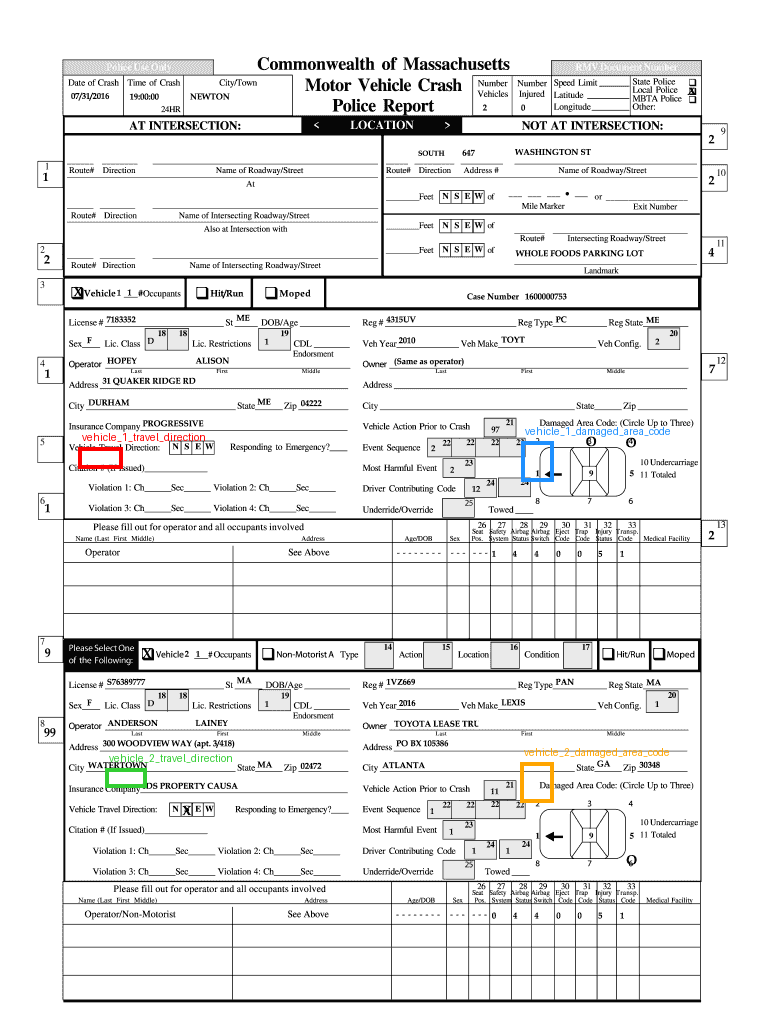

In [26]:
bbox_prompt = """
Find the vehicle travel direction and damaged area codes for Vehicles 1 and 2 in this police report form.

Return JSON with this schema:
[
  {"label": "vehicle_1_travel_direction", "bbox": [x_min, y_min, x_max, y_max]},
  {"label": "vehicle_1_damaged_area_code", "bbox": [x_min, y_min, x_max, y_max]},
  {"label": "vehicle_2_travel_direction", "bbox": [x_min, y_min, x_max, y_max]},
  {"label": "vehicle_2_damaged_area_code", "bbox": [x_min, y_min, x_max, y_max]}
]

Use discrete normalized coordinates between 0 and 999.
Return JSON only.
"""

police_form_path = f"../../examples/multimodal/images/police_form.png"
police_form_image_url = image_to_data_url(police_form_path)

bbox_response = client.responses.create(
    model="galapagos-alpha",
    input=[
        {
            "role": "user",
            "content": [
                {"type": "input_text", "text": bbox_prompt},
                {
                    "type": "input_image",
                    "image_url": police_form_image_url,
                    "detail": "original",
                },
            ],
        }
    ],
)
bbox_results = maybe_parse_json(bbox_response.output_text)
if bbox_results is None:
    raise ValueError(bbox_response.output_text)

display(pd.DataFrame(bbox_results))

def denormalize_bbox(bbox: list[int], width: int, height: int) -> list[int]:
    x_min, y_min, x_max, y_max = bbox
    return [
        round(x_min * (width - 1) / 999),
        round(y_min * (height - 1) / 999),
        round(x_max * (width - 1) / 999),
        round(y_max * (height - 1) / 999),
    ]

annotated_image = Image.open(police_form_path).convert("RGB")
draw = ImageDraw.Draw(annotated_image)
width, height = annotated_image.size
palette = ["red", "dodgerblue", "limegreen", "orange", "magenta", "cyan"]

for index, item in enumerate(bbox_results):
    color = palette[index % len(palette)]
    pixel_bbox = denormalize_bbox(item["bbox"], width, height)
    draw.rectangle(pixel_bbox, outline=color, width=4)
    draw.text((pixel_bbox[0] + 4, max(0, pixel_bbox[1] - 16)), item["label"], fill=color)

display(annotated_image)


## 4. Raise reasoning effort when the image is readable but the answer is compositional

Once the image is readable, the next bottleneck is often reasoning instead of perception. That happens with charts, tables, forms, and technical drawings where the answer depends on evidence from several different parts of the page.

The floorplan below is a stand-in for a more complex architectural or CAD-style example. It has enough structure to show the tradeoff clearly while still giving us known answers.

One practical lesson from this kind of benchmark is that higher reasoning is not free. If the default pass already solves the task, turning reasoning up just adds latency. Use it selectively.

![Apartment floorplan](images/apartment_floorplan.png)


In [28]:
floorplan_prompt = """
Inspect this apartment floorplan and return JSON with these keys:
- total_named_rooms_excluding_hallways_and_closets
- largest_room
- room_immediately_east_of_kitchen
- room_immediately_south_of_study
- overall_width_ft
- overall_height_ft

Rules:
- Use the room labels and dimension annotations that are visible on the drawing.
- Return integers for numeric fields.
- Return JSON only.
"""

floorplan_expected = {
    "total_named_rooms_excluding_hallways_and_closets": 7,
    "largest_room": "Living Room",
    "room_immediately_east_of_kitchen": "Dining",
    "room_immediately_south_of_study": "Bedroom 2",
    "overall_width_ft": 36,
    "overall_height_ft": 24,
}
floorplan_tolerances = {
    "overall_width_ft": 0,
    "overall_height_ft": 0,
}


def score_floorplan_response(parsed: dict | None):
    def normalize_value(value):
        if value is None:
            return None
        text = unicodedata.normalize("NFKD", str(value))
        text = text.encode("ascii", "ignore").decode("ascii")
        text = text.lower()
        return re.sub(r"[^a-z0-9]+", " ", text).strip()

    def values_match(predicted, expected, tolerance: float | None = None) -> bool:
        if isinstance(expected, list):
            if not isinstance(predicted, list):
                predicted = [] if predicted is None else [predicted]
            left = sorted(normalize_value(item) for item in predicted if item is not None)
            right = sorted(normalize_value(item) for item in expected if item is not None)
            return left == right

        if isinstance(expected, (int, float)):
            try:
                predicted_float = float(predicted)
            except (TypeError, ValueError):
                return False
            tolerance = 0 if tolerance is None else tolerance
            return abs(predicted_float - float(expected)) <= tolerance

        return normalize_value(predicted) == normalize_value(expected)

    rows = []
    for field, expected_value in floorplan_expected.items():
        predicted_value = None if parsed is None else parsed.get(field)
        match = values_match(
            predicted_value,
            expected_value,
            floorplan_tolerances.get(field),
        )
        rows.append(
            {
                "field": field,
                "expected": expected_value,
                "predicted": predicted_value,
                "match": match,
            }
        )
    frame = pd.DataFrame(rows)
    accuracy = frame["match"].mean() if not frame.empty else 0.0
    return frame, accuracy


floorplan_path = f"../../examples/multimodal/images/apartment_floorplan.png"
floorplan_image_url = image_to_data_url(floorplan_path)
floorplan_model = "galapagos-alpha"

floorplan_results = []
for reasoning_effort in [None, "high"]:
    started_at = time.perf_counter()
    request = {
        "model": floorplan_model,
        "input": [
            {
                "role": "user",
                "content": [
                    {"type": "input_text", "text": floorplan_prompt},
                    {
                        "type": "input_image",
                        "image_url": floorplan_image_url,
                        "detail": "original",
                    },
                ],
            }
        ],
    }
    if reasoning_effort is not None:
        request["reasoning"] = {"effort": reasoning_effort}
    response = client.responses.create(**request)
    elapsed_s = round(time.perf_counter() - started_at, 2)
    parsed = maybe_parse_json(response.output_text)
    score_frame, accuracy = score_floorplan_response(parsed)
    usage = response_usage(response)
    floorplan_results.append(
        {
            "reasoning": reasoning_effort or "default",
            "elapsed_s": elapsed_s,
            "field_accuracy": round(float(accuracy), 3),
            "matches": int(score_frame["match"].sum()),
            "total_fields": int(len(score_frame)),
            "output_tokens": usage.get("output_tokens"),
            "parsed": parsed,
            "score_frame": score_frame,
            "raw_output": response.output_text,
        }
    )

display(
    pd.DataFrame(
        [
            {
                key: result[key]
                for key in ["reasoning", "elapsed_s", "field_accuracy", "matches", "total_fields", "output_tokens"]
            }
            for result in floorplan_results
        ]
    )
)

for result in floorplan_results:
    display(Markdown(f"### {result['reasoning']} reasoning"))
    if result["parsed"] is not None:
        print(json.dumps(result["parsed"], indent=2))
    else:
        clipped = (
            result["raw_output"]
            if len(result["raw_output"]) <= 1800
            else result["raw_output"][:1800] + "\n\n...[truncated]..."
        )
        display(Markdown(f"### {result['reasoning']} reasoning raw output\n\n```text\n{clipped}\n```"))
    display(result["score_frame"])


,reasoning,elapsed_s,field_accuracy,matches,total_fields,output_tokens
0,default,2.08,1.0,6,6,62
1,high,7.39,1.0,6,6,471


### default reasoning

{
  "total_named_rooms_excluding_hallways_and_closets": 7,
  "largest_room": "Living Room",
  "room_immediately_east_of_kitchen": "Dining",
  "room_immediately_south_of_study": "Bedroom 2",
  "overall_width_ft": 36,
  "overall_height_ft": 24
}


,field,expected,predicted,match
0,total_named_rooms_excluding_hallways_and_closets,7,7,True
1,largest_room,Living Room,Living Room,True
2,room_immediately_east_of_kitchen,Dining,Dining,True
3,room_immediately_south_of_study,Bedroom 2,Bedroom 2,True
4,overall_width_ft,36,36,True
5,overall_height_ft,24,24,True


### high reasoning

{
  "total_named_rooms_excluding_hallways_and_closets": 7,
  "largest_room": "Living Room",
  "room_immediately_east_of_kitchen": "Dining",
  "room_immediately_south_of_study": "Bedroom 2",
  "overall_width_ft": 36,
  "overall_height_ft": 24
}


,field,expected,predicted,match
0,total_named_rooms_excluding_hallways_and_closets,7,7,True
1,largest_room,Living Room,Living Room,True
2,room_immediately_east_of_kitchen,Dining,Dining,True
3,room_immediately_south_of_study,Bedroom 2,Bedroom 2,True
4,overall_width_ft,36,36,True
5,overall_height_ft,24,24,True


### Chart example

The same reasoning pattern helps with chart QA. If the answer depends on reading multiple series, comparing adjacent intervals, and estimating values rather than extracting a single label, raise reasoning effort before you reach for a tool.

![Line chart](../../images/NotRealCorp_chart.png)


In [29]:
chart_prompt = """
Inspect this line chart and return JSON with these keys:
- largest_qoq_increase: {"channel": ..., "from_quarter": ..., "to_quarter": ..., "approx_delta_millions": ...}
- largest_qoq_drop: {"channel": ..., "from_quarter": ..., "to_quarter": ..., "approx_delta_millions": ...}
- fastest_growing_channel_overall

Rules:
- Use approximate values only when exact values are not printed.
- Base the answer on the visible lines and quarter labels.
- Return JSON only.
"""

chart_path = f"../../images/NotRealCorp_chart.png"
chart_image_url = image_to_data_url(chart_path)

chart_response = client.responses.create(
    model="galapagos-alpha",
    reasoning={"effort": "high"},
    input=[
        {
            "role": "user",
            "content": [
                {"type": "input_text", "text": chart_prompt},
                {
                    "type": "input_image",
                    "image_url": chart_image_url,
                    "detail": "original",
                },
            ],
        }
    ],
)
chart_json = maybe_parse_json(chart_response.output_text)
if chart_json is None:
    raise ValueError(chart_response.output_text)

print(json.dumps(chart_json, indent=2))


{
  "largest_qoq_increase": {
    "channel": "Online Sales",
    "from_quarter": "2021 Q4",
    "to_quarter": "2022 Q1",
    "approx_delta_millions": 0.15
  },
  "largest_qoq_drop": {
    "channel": "Retail Partners",
    "from_quarter": "2023 Q4",
    "to_quarter": "2024 Q1",
    "approx_delta_millions": -0.05
  },
  "fastest_growing_channel_overall": "Online Sales"
}


### Tournament bracket example

Dense tournament brackets are a good stress test for long-range visual reasoning. The model has to read mirrored trees, keep the left and right halves separate, then use the central championship score boxes to answer the actual question.

This is the example your colleague added upstream. In the live runs I checked while merging, both `gpt-5` and `galapagos-alpha` recovered the same champions, but `gpt-5` tended to preserve seed numbers in the team strings and took much longer on the same prompt.

![Tournament bracket](images/bracket.png)


In [30]:
bracket_prompt = """
Inspect this tournament bracket image and return JSON with these keys:
- left_bracket_title
- right_bracket_title
- mens_champion_team
- womens_champion_team
- mens_runner_up_team
- womens_runner_up_team

Rules:
- Use the visible central championship score boxes.
- Team labels may include seeds; if you include a seed, keep it attached to the same string.
- Return JSON only.
"""

bracket_path = f"../../examples/multimodal/images/bracket.png"
bracket_image_url = image_to_data_url(bracket_path)
comparison_models = ["gpt-5", "galapagos-alpha"]

bracket_runs = []
for model in comparison_models:
    started_at = time.perf_counter()
    response = client.responses.create(
        model=model,
        input=[
            {
                "role": "user",
                "content": [
                    {"type": "input_text", "text": bracket_prompt},
                    {
                        "type": "input_image",
                        "image_url": bracket_image_url,
                        "detail": "original",
                    },
                ],
            }
        ],
    )
    elapsed_s = round(time.perf_counter() - started_at, 2)
    parsed = maybe_parse_json(response.output_text)
    usage = response_usage(response)
    bracket_runs.append(
        {
            "model": model,
            "elapsed_s": elapsed_s,
            "output_tokens": usage.get("output_tokens"),
            "parsed": parsed,
            "raw_output": response.output_text,
        }
    )

display(
    pd.DataFrame(
        [
            {
                key: result[key]
                for key in ["model", "elapsed_s", "output_tokens"]
            }
            for result in bracket_runs
        ]
    )
)

for result in bracket_runs:
    display(Markdown(f"### {result['model']} bracket output"))
    if result["parsed"] is not None:
        print(json.dumps(result["parsed"], indent=2, ensure_ascii=False))
    else:
        clipped = (
            result["raw_output"]
            if len(result["raw_output"]) <= 1800
            else result["raw_output"][:1800] + "\n\n...[truncated]..."
        )
        display(Markdown(f"### {result['model']} bracket raw output\n\n```text\n{clipped}\n```"))


,model,elapsed_s,output_tokens
0,gpt-5,28.34,1446
1,galapagos-alpha,2.13,68


### gpt-5 bracket output

{
  "left_bracket_title": "Women's Bracket",
  "right_bracket_title": "Men's Bracket",
  "mens_champion_team": "Connecticut 4",
  "womens_champion_team": "L.S.U. 3",
  "mens_runner_up_team": "5 S.D. State",
  "womens_runner_up_team": "2 Iowa"
}


### galapagos-alpha bracket output

{
  "left_bracket_title": "Women’s Bracket",
  "right_bracket_title": "Men’s Bracket",
  "mens_champion_team": "Connecticut 4",
  "womens_champion_team": "L.S.U. 3",
  "mens_runner_up_team": "5 S.D. State",
  "womens_runner_up_team": "2 Iowa"
}


## 5. Use Code Interpreter when the task needs a real second look

Native vision is often enough. Code Interpreter becomes useful when a human would open the image in another tab, zoom into several regions, rotate something, or sanity-check a reading before answering.

Reach for Code Interpreter when:

- the page is dense and the relevant evidence is scattered across multiple regions
- you expect to crop, zoom, rotate, or inspect intermediate views
- qualitative accuracy matters more than minimum latency

While drafting this notebook on March 4, 2026, the tool-assisted version of this police-form task took about `104.8s` and made `2` Code Interpreter calls. That is useful evidence, but it is not a generic speed story. Treat Code Interpreter here as a multi-pass inspection tool with an explicit latency tradeoff, not a free performance win.

The cell below compares a native pass with a tool-assisted pass on the same police-form question. This is opt-in because tool calls are slower and more expensive than a single native vision pass.


In [ ]:
ci_prompt = """
Read the police report form and return JSON with these keys:
- vehicle_1_travel_direction
- vehicle_1_damaged_area_code
- vehicle_2_travel_direction
- vehicle_2_damaged_area_code

Rules:
- If the form is hard to read, inspect the relevant regions before answering.
- Return JSON only.
"""

run_code_interpreter_comparison = False
ci_model = "galapagos-alpha"
police_form_path = f"../../examples/multimodal/images/police_form.png"
police_form_image_url = image_to_data_url(police_form_path)

if run_code_interpreter_comparison:
    native_started = time.perf_counter()
    native_response = client.responses.create(
        model=ci_model,
        reasoning={"effort": "high"},
        input=[
            {
                "role": "user",
                "content": [
                    {"type": "input_text", "text": ci_prompt},
                    {
                        "type": "input_image",
                        "image_url": police_form_image_url,
                        "detail": "original",
                    },
                ],
            }
        ],
    )
    native_elapsed = round(time.perf_counter() - native_started, 2)

    with police_form_path.open("rb") as asset_file:
        uploaded_file = client.files.create(file=asset_file, purpose="user_data")

    ci_started = time.perf_counter()
    ci_response = client.responses.create(
        model=ci_model,
        instructions=(
            "You are an expert document analyst. Use Code Interpreter before answering. "
            "Inspect the uploaded file, crop or zoom if needed, then answer in JSON."
        ),
        tools=[
            {
                "type": "code_interpreter",
                "container": {
                    "type": "auto",
                    "memory_limit": "4g",
                    "file_ids": [uploaded_file.id],
                },
            }
        ],
        include=["code_interpreter_call.outputs"],
        input=[
            {
                "role": "user",
                "content": [
                    {"type": "input_text", "text": ci_prompt + " Use the tool at least once before answering."},
                    {
                        "type": "input_image",
                        "image_url": police_form_image_url,
                        "detail": "original",
                    },
                ],
            }
        ],
    )
    ci_elapsed = round(time.perf_counter() - ci_started, 2)

    ci_call_count = sum(
        1
        for item in (ci_response.output or [])
        if (item.get("type") if isinstance(item, dict) else getattr(item, "type", None))
        == "code_interpreter_call"
    )

    comparison_df = pd.DataFrame(
        [
            {
                "mode": "native vision",
                "elapsed_s": native_elapsed,
                "code_interpreter_calls": 0,
                "output_tokens": response_usage(native_response).get("output_tokens"),
            },
            {
                "mode": "code interpreter",
                "elapsed_s": ci_elapsed,
                "code_interpreter_calls": ci_call_count,
                "output_tokens": response_usage(ci_response).get("output_tokens"),
            },
        ]
    )
    display(comparison_df)
    native_clipped = (
        native_response.output_text
        if len(native_response.output_text) <= 1800
        else native_response.output_text[:1800] + "\n\n...[truncated]..."
    )
    display(Markdown(f"### Native vision output\n\n```text\n{native_clipped}\n```"))

    ci_clipped = (
        ci_response.output_text
        if len(ci_response.output_text) <= 1800
        else ci_response.output_text[:1800] + "\n\n...[truncated]..."
    )
    display(Markdown(f"### Code Interpreter output\n\n```text\n{ci_clipped}\n```"))
else:
    print(
        "Skipping the Code Interpreter comparison. Set run_code_interpreter_comparison = True "
        "if you want to measure native vs tool-assisted latency on the police-form task."
    )


## 6. If you cannot use Code Interpreter, build a narrow crop-and-rerun pipeline

In restricted environments, you may not want to grant the model a general Python sandbox. A practical alternative is a two-stage workflow:

1. localize the field or region you care about
2. crop that region locally
3. rerun a smaller, more focused prompt on the crop

This often recovers much of the value of multi-pass inspection while keeping the control surface small.


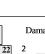

[
  "22"
]


In [32]:
police_form_path = f"../../examples/multimodal/images/police_form.png"

target_region = next(
    item for item in bbox_results if item["label"] == "vehicle_2_damaged_area_code"
)

source_image = Image.open(police_form_path).convert("RGB")
width, height = source_image.size

def denormalize_bbox(bbox: list[int], width: int, height: int) -> list[int]:
    x_min, y_min, x_max, y_max = bbox
    return [
        round(x_min * (width - 1) / 999),
        round(y_min * (height - 1) / 999),
        round(x_max * (width - 1) / 999),
        round(y_max * (height - 1) / 999),
    ]

x_min, y_min, x_max, y_max = denormalize_bbox(target_region["bbox"], width, height)
pad_x = round((x_max - x_min) * 0.18)
pad_y = round((y_max - y_min) * 0.18)

crop = source_image.crop(
    (
        max(0, x_min - pad_x),
        max(0, y_min - pad_y),
        min(width, x_max + pad_x),
        min(height, y_max + pad_y),
    )
)

tmp = tempfile.NamedTemporaryFile(suffix=".png", delete=False)
crop_path = Path(tmp.name)
tmp.close()
crop.save(crop_path)

display(crop)

crop_prompt = """
Read the circled damaged-area code or codes in this cropped police-form region.

Return JSON with one key:
- damaged_area_codes: an array of strings

Return JSON only.
"""

crop_image_url = image_to_data_url(crop_path)

crop_response = client.responses.create(
    model="galapagos-alpha",
    input=[
        {
            "role": "user",
            "content": [
                {"type": "input_text", "text": crop_prompt},
                {
                    "type": "input_image",
                    "image_url": crop_image_url,
                    "detail": "original",
                },
            ],
        }
    ],
)
crop_json = maybe_parse_json(crop_response.output_text)
if crop_json is None:
    raise ValueError(crop_response.output_text)

print(json.dumps(crop_json, indent=2))


## Distilled guidance

- Start with native vision and `detail="auto"` for ordinary pages.
- Move to `detail="original"` for dense scans, handwriting, screenshots, and anything with tiny labels.
- Keep any sampling controls your model exposes fixed when you benchmark; model surfaces differ.
- Turn verbosity high only when you need faithful transcription. Otherwise, let the model stay concise.
- For region-level workflows, ask for normalized boxes and keep the coordinate system stable.
- Add `reasoning={"effort": "high"}` when the answer depends on multiple regions of a chart, table, form, floorplan, or technical diagram.
- Use Code Interpreter when a human would need to zoom, crop, rotate, or inspect several subregions before answering.
- If Code Interpreter is not available, emulate the same pattern with a narrow localize -> crop -> rerun workflow.
- Before making launch claims, benchmark the exact asset, prompt, detail level, tool configuration, and any exposed sampling settings you plan to publish.